# Final Faithfulness and StereoSet Results

This notebook is intended as the **final thesis-ready results notebook** for two critical parts of Attention Atlas:

1. **Faithfulness validation** of the bias-analysis explanations;
2. **StereoSet benchmark evaluation** and its connection to internal attention mechanisms.

The goal is to move from exploratory outputs to tables and figures that can be used directly in the dissertation.

In [19]:
# Import libraries, define paths, and configure plotting for the final faithfulness and StereoSet analysis notebook.

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'attention_app').exists():
    ROOT = ROOT.parent

FAITH_DIR = ROOT / 'notebooks' / 'final_faithfulness_results'
STEREO_DIR = ROOT / 'attention_app' / 'bias' / 'stereoset' / 'results'
OUT_DIR = ROOT / 'notebooks' / 'final_thesis_tables'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

def infer_attention_source(exec_summary: dict, metadata: dict, encoder_model: str) -> str:
    source = exec_summary.get('attention_source') or metadata.get('attention_source')
    if source in {'base', 'gusnet', 'explicit'}:
        return source
    enc = (encoder_model or '').lower()
    if 'gus-net' in enc or 'gus_net' in enc:
        return 'gusnet'
    return 'base'


def format_attention_source(source: str) -> str:
    return {'base': 'Base Encoder', 'gusnet': 'GUS-Net', 'explicit': 'Explicit Encoder'}.get(source, source.title())

## Faithfulness Results

This section expects thesis-ready faithfulness JSON outputs to be stored in `notebooks/final_faithfulness_results/`.
Each JSON file should contain a batch report with the same schema produced by the Bias tab batch pipeline, including `faithfulness_summary` and `per_sentence_results`.

If the folder is empty, the notebook still shows the analysis structure and expected outputs, but the quantitative tables will remain empty until the reports are generated.

In [20]:
# Load all available batch faithfulness reports and extract model-level summary metrics for thesis tables.

faithfulness_files = sorted(FAITH_DIR.glob('*.json'))
faithfulness_reports = []
for fp in faithfulness_files:
    with open(fp, 'r', encoding='utf-8') as f:
        faithfulness_reports.append(json.load(f))

faithfulness_rows = []
for report in faithfulness_reports:
    summary = report.get('faithfulness_summary', {})
    exec_summary = report.get('executive_summary', {})
    metadata = report.get('metadata', {})
    model_label = exec_summary.get('model_used', exec_summary.get('model_key'))
    model_key = exec_summary.get('model_key')
    encoder_model = exec_summary.get('encoder_model')
    attention_source = infer_attention_source(exec_summary, metadata, encoder_model)
    attention_source_label = format_attention_source(attention_source)
    faithfulness_rows.append({
        'model_label': model_label,
        'model_key': model_key,
        'encoder_model': encoder_model,
        'attention_source': attention_source,
        'attention_source_label': attention_source_label,
        'report_label': f'{model_label} ({attention_source_label})',
        'n_sentences': exec_summary.get('sentences_analyzed'),
        'avg_top_head_rho': summary.get('ig_analysis', {}).get('avg_top_head_rho'),
        'heads_with_significant_correlation': summary.get('ig_analysis', {}).get('heads_with_significant_correlation'),
        'avg_topk_jaccard': summary.get('ig_analysis', {}).get('avg_topk_jaccard'),
        'avg_topk_rbo': summary.get('ig_analysis', {}).get('avg_topk_rbo'),
        'avg_representation_impact': summary.get('ablation_analysis', {}).get('avg_representation_impact'),
        'avg_kl_divergence': summary.get('ablation_analysis', {}).get('avg_kl_divergence'),
        'avg_perturb_vs_ig_rho': summary.get('perturbation_analysis', {}).get('avg_perturb_vs_ig_rho'),
        'avg_perturb_vs_attention_rho': summary.get('perturbation_analysis', {}).get('avg_perturb_vs_attention_rho'),
        'avg_lrp_vs_ig_rho': summary.get('lrp_analysis', {}).get('avg_lrp_vs_ig_rho'),
        'avg_lrp_vs_attention_rho': summary.get('lrp_analysis', {}).get('avg_lrp_vs_attention_rho'),
    })

faithfulness_summary_df = pd.DataFrame(faithfulness_rows)
if len(faithfulness_summary_df):
    faithfulness_summary_df = faithfulness_summary_df.sort_values(['model_label', 'attention_source']).reset_index(drop=True)
    faithfulness_summary_df.to_csv(OUT_DIR / 'faithfulness_summary_table.csv', index=False)

    comparison_metrics = [
        'avg_top_head_rho',
        'avg_topk_jaccard',
        'avg_topk_rbo',
        'avg_representation_impact',
        'avg_kl_divergence',
        'avg_perturb_vs_ig_rho',
        'avg_lrp_vs_ig_rho',
    ]
    faithfulness_comparison_df = faithfulness_summary_df.pivot_table(
        index=['model_label', 'model_key'],
        columns='attention_source_label',
        values=comparison_metrics,
        aggfunc='first',
    )
    faithfulness_comparison_df.columns = [f'{metric}__{source}' for metric, source in faithfulness_comparison_df.columns]
    faithfulness_comparison_df = faithfulness_comparison_df.reset_index()
    faithfulness_comparison_df.to_csv(OUT_DIR / 'faithfulness_summary_comparison_table.csv', index=False)
else:
    faithfulness_comparison_df = pd.DataFrame()

faithfulness_summary_df

,model_label,model_key,encoder_model,attention_source,attention_source_label,report_label,n_sentences,avg_top_head_rho,heads_with_significant_correlation,avg_topk_jaccard,avg_topk_rbo,avg_representation_impact,avg_kl_divergence,avg_perturb_vs_ig_rho,avg_perturb_vs_attention_rho,avg_lrp_vs_ig_rho,avg_lrp_vs_attention_rho
0,GUS-Net (BERT),gusnet-bert,bert-base-uncased,base,Base Encoder,GUS-Net (BERT) (Base Encoder),250,0.5395,3777,0.3721,0.1409,0.0043,0.0069,0.1633,-0.0757,0.7039,-0.0349
1,GUS-Net (BERT),gusnet-bert,bert-base-uncased,base,Base Encoder,GUS-Net (BERT) (Base Encoder),250,0.5395,3777,0.3721,0.1409,0.0043,0.0069,0.1633,-0.0757,0.7039,-0.0349
2,GUS-Net (BERT),gusnet-bert,pinthoz/gus-net-bert,gusnet,GUS-Net,GUS-Net (BERT) (GUS-Net),250,0.5647,4667,0.4002,0.1468,0.0073,0.0091,0.2278,-0.1101,0.8377,-0.0662
3,GUS-Net (GPT-2),gusnet-gpt2,gpt2,base,Base Encoder,GUS-Net (GPT-2) (Base Encoder),250,0.5019,1860,0.4871,0.1316,0.0000,0.0009,0.0566,0.2319,0.4229,0.0026
4,GUS-Net (GPT-2),gusnet-gpt2,pinthoz/gus-net-gpt2,gusnet,GUS-Net,GUS-Net (GPT-2) (GUS-Net),250,0.5122,2925,0.6159,0.1548,0.0027,0.0011,0.5225,0.5255,0.9906,0.1947


In [21]:
# Build a side-by-side Base vs GUS-Net comparison table for the same bias model whenever both report variants are available.

if len(faithfulness_comparison_df):
    faithfulness_comparison_df
else:
    print('No side-by-side Base vs GUS-Net faithfulness comparison available yet.')

In [ ]:
# Quantify the Base-to-GUS-Net change for the main faithfulness metrics and export a thesis-ready delta table.

if len(faithfulness_summary_df) and {'Base Encoder', 'GUS-Net'}.issubset(set(faithfulness_summary_df['attention_source_label'])):
    delta_metrics = [
        'avg_top_head_rho',
        'avg_topk_jaccard',
        'avg_topk_rbo',
        'avg_representation_impact',
        'avg_kl_divergence',
        'avg_perturb_vs_ig_rho',
        'avg_lrp_vs_ig_rho',
    ]
    base_vs_gus_delta_df = faithfulness_summary_df.pivot_table(
        index=['model_label', 'model_key'],
        columns='attention_source_label',
        values=delta_metrics,
        aggfunc='first',
    )
    delta_rows = []
    for idx in base_vs_gus_delta_df.index:
        row = {'model_label': idx[0], 'model_key': idx[1]}
        for metric in delta_metrics:
            base_val = base_vs_gus_delta_df.loc[idx].get((metric, 'Base Encoder'))
            gus_val = base_vs_gus_delta_df.loc[idx].get((metric, 'GUS-Net'))
            row[f'{metric}_base'] = base_val
            row[f'{metric}_gusnet'] = gus_val
            row[f'{metric}_delta_gus_minus_base'] = (gus_val - base_val) if pd.notna(base_val) and pd.notna(gus_val) else np.nan
        delta_rows.append(row)
    base_vs_gus_delta_df = pd.DataFrame(delta_rows)
    base_vs_gus_delta_df.to_csv(OUT_DIR / 'faithfulness_base_vs_gusnet_delta_table.csv', index=False)
    base_vs_gus_delta_df
else:
    base_vs_gus_delta_df = pd.DataFrame()
    print('Generate both Base and GUS-Net faithfulness reports to compute deltas.')

In [23]:
# Build a head-level faithfulness table from per-sentence outputs, allowing identification of highly faithful and weakly faithful heads.

head_rows = []
for report in faithfulness_reports:
    exec_summary = report.get('executive_summary', {})
    metadata = report.get('metadata', {})
    model_label = exec_summary.get('model_used', exec_summary.get('model_key'))
    model_key = exec_summary.get('model_key')
    encoder_model = exec_summary.get('encoder_model')
    attention_source = infer_attention_source(exec_summary, metadata, encoder_model)
    attention_source_label = format_attention_source(attention_source)
    for sent in report.get('per_sentence_results', []):
        ig = sent.get('ig_analysis', {})
        abl = sent.get('ablation_analysis', [])
        abl_lookup = {(a['layer'], a['head']): a for a in abl if 'layer' in a and 'head' in a}
        for row in ig.get('ig_attention_correlations', []):
            key = (row.get('layer'), row.get('head'))
            abl_row = abl_lookup.get(key, {})
            head_rows.append({
                'model_label': model_label,
                'model_key': model_key,
                'encoder_model': encoder_model,
                'attention_source': attention_source,
                'attention_source_label': attention_source_label,
                'sentence_index': sent.get('index'),
                'layer': row.get('layer'),
                'head': row.get('head'),
                'ig_rho': row.get('spearman_rho'),
                'ig_p': row.get('p_value'),
                'bar': row.get('bar'),
                'representation_impact': abl_row.get('representation_impact'),
                'kl_divergence': abl_row.get('kl_divergence'),
            })

faithfulness_heads_df = pd.DataFrame(head_rows)
if len(faithfulness_heads_df):
    grouped_heads = faithfulness_heads_df.groupby(['model_label', 'model_key', 'attention_source_label', 'layer', 'head'], as_index=False).mean(numeric_only=True)
    grouped_heads['abs_ig_rho'] = grouped_heads['ig_rho'].abs()
    grouped_heads.to_csv(OUT_DIR / 'faithfulness_heads_table.csv', index=False)
    display(grouped_heads.sort_values(['model_label', 'attention_source_label', 'abs_ig_rho'], ascending=[True, True, False]).groupby(['model_label', 'attention_source_label']).head(10))
else:
    grouped_heads = pd.DataFrame()
    print('No faithfulness head-level reports found yet.')

,model_label,model_key,attention_source_label,layer,head,sentence_index,ig_rho,ig_p,bar,representation_impact,kl_divergence,abs_ig_rho
102,GUS-Net (BERT),gusnet-bert,Base Encoder,8,6,111.336283,0.549052,0.100918,0.129324,NaN,NaN,0.549052
56,GUS-Net (BERT),gusnet-bert,Base Encoder,4,8,125.107438,0.541022,0.093102,0.251746,NaN,NaN,0.541022
92,GUS-Net (BERT),gusnet-bert,Base Encoder,7,8,127.213115,0.533640,0.096521,0.378463,NaN,NaN,0.533640
88,GUS-Net (BERT),gusnet-bert,Base Encoder,7,4,124.134146,0.533426,0.109844,0.652413,NaN,NaN,0.533426
140,GUS-Net (BERT),gusnet-bert,Base Encoder,11,8,125.385827,0.533294,0.100362,0.911339,0.013488,0.016249,0.533294
65,GUS-Net (BERT),gusnet-bert,Base Encoder,5,5,124.603960,0.532098,0.124478,0.184685,NaN,NaN,0.532098
0,GUS-Net (BERT),gusnet-bert,Base Encoder,0,0,137.806452,0.529368,0.118662,0.982992,0.002020,0.004475,0.529368
75,GUS-Net (BERT),gusnet-bert,Base Encoder,6,3,110.384615,0.526609,0.112792,0.184235,NaN,NaN,0.526609
123,GUS-Net (BERT),gusnet-bert,Base Encoder,10,3,130.417582,0.524032,0.102326,0.304410,NaN,NaN,0.524032
91,GUS-Net (BERT),gusnet-bert,Base Encoder,7,7,120.779661,0.522931,0.100699,0.116774,NaN,NaN,0.522931


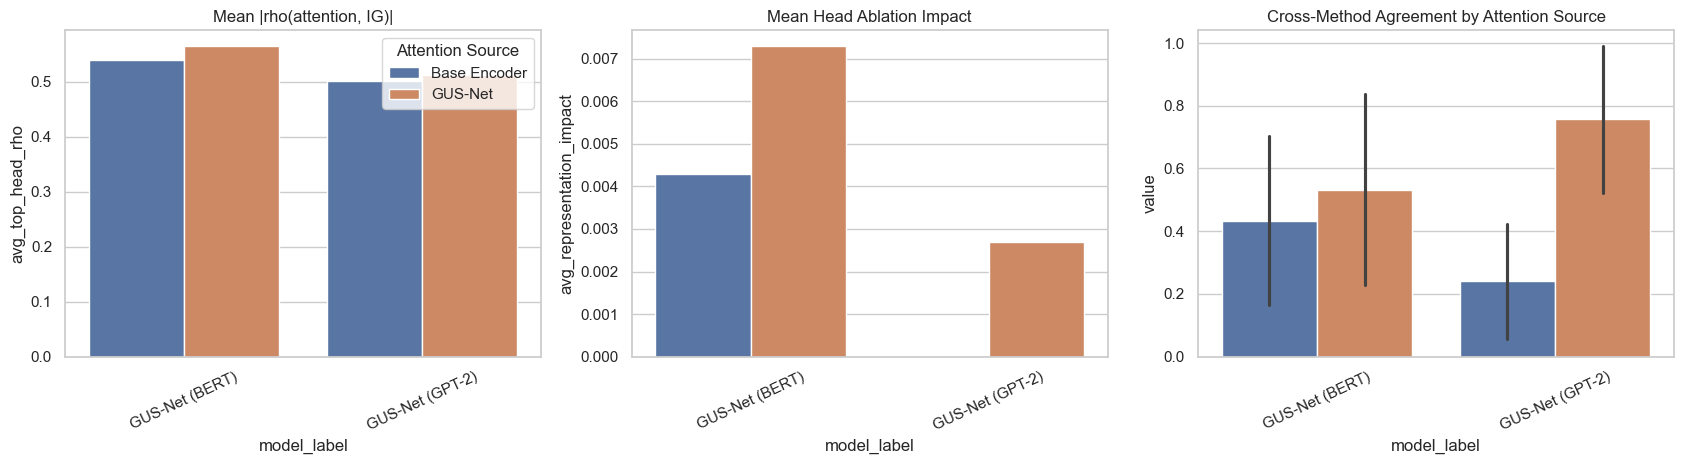

In [24]:
# Create publication-style summary figures for the faithfulness chapter if final reports are available.

if len(faithfulness_summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    hue_order = ['Base Encoder', 'GUS-Net'] if 'GUS-Net' in set(faithfulness_summary_df['attention_source_label']) else sorted(faithfulness_summary_df['attention_source_label'].unique())

    sns.barplot(data=faithfulness_summary_df, x='model_label', y='avg_top_head_rho', hue='attention_source_label', hue_order=hue_order, ax=axes[0])
    axes[0].set_title('Mean |rho(attention, IG)|')
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].legend(title='Attention Source')

    sns.barplot(data=faithfulness_summary_df, x='model_label', y='avg_representation_impact', hue='attention_source_label', hue_order=hue_order, ax=axes[1])
    axes[1].set_title('Mean Head Ablation Impact')
    axes[1].tick_params(axis='x', rotation=25)
    if axes[1].legend_ is not None:
        axes[1].legend_.remove()

    melt_cols = [c for c in ['avg_perturb_vs_ig_rho', 'avg_lrp_vs_ig_rho'] if c in faithfulness_summary_df.columns]
    aux_df = faithfulness_summary_df.melt(id_vars=['model_label', 'attention_source_label'], value_vars=melt_cols, var_name='metric', value_name='value')
    aux_df = aux_df.dropna(subset=['value']).copy()
    aux_df['metric'] = aux_df['metric'].map({
        'avg_perturb_vs_ig_rho': 'Perturbation vs IG',
        'avg_lrp_vs_ig_rho': 'LRP vs IG',
    })
    if len(aux_df):
        sns.barplot(data=aux_df, x='model_label', y='value', hue='attention_source_label', hue_order=hue_order, ax=axes[2])
        axes[2].set_title('Cross-Method Agreement by Attention Source')
        axes[2].tick_params(axis='x', rotation=25)
        if axes[2].legend_ is not None:
            axes[2].legend_.remove()
    else:
        axes[2].axis('off')
        axes[2].text(0.5, 0.5, 'No cross-method agreement data available yet.', ha='center', va='center', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print('No faithfulness summary reports available yet.')

## StereoSet Results

This section builds thesis-ready benchmark tables from the precomputed StereoSet JSON files already present in the repository.

In [25]:
# Load all StereoSet result JSON files and construct an overall benchmark comparison table.

stereoset_files = sorted(STEREO_DIR.glob('stereoset_precomputed*.json'))
stereoset_payloads = []
for fp in stereoset_files:
    with open(fp, 'r', encoding='utf-8') as f:
        data = json.load(f)
    data['_file'] = fp.name
    stereoset_payloads.append(data)

overall_rows = []
category_rows = []
head_rows = []

for payload in stereoset_payloads:
    meta = payload.get('metadata', {})
    scores = payload.get('scores', {})
    overall = scores.get('overall', {})
    overall_rows.append({
        'file': payload['_file'],
        'model': meta.get('model'),
        'scoring_method': meta.get('scoring_method'),
        'n_examples': overall.get('n', meta.get('total_examples')),
        'ss': overall.get('ss'),
        'lms': overall.get('lms'),
        'icat': overall.get('icat'),
        'mean_bias_score': overall.get('mean_bias_score'),
        'significant_features': meta.get('significant_features'),
    })

    for category, cat_scores in scores.get('by_category', {}).items():
        category_rows.append({
            'model': meta.get('model'),
            'category': category,
            'ss': cat_scores.get('ss'),
            'lms': cat_scores.get('lms'),
            'icat': cat_scores.get('icat'),
            'n': cat_scores.get('n'),
            'mean_bias_score': cat_scores.get('mean_bias_score'),
        })

    for rank, head in enumerate(payload.get('sensitive_heads', [])[:20], 1):
        head_rows.append({
            'model': meta.get('model'),
            'rank': rank,
            'layer': head.get('layer'),
            'head': head.get('head'),
            'variance': head.get('variance'),
            'correlation': head.get('correlation'),
            'n_features': head.get('n_features'),
            'best_feature': head.get('best_feature'),
        })

stereoset_overall_df = pd.DataFrame(overall_rows).sort_values('model').reset_index(drop=True)
stereoset_category_df = pd.DataFrame(category_rows).sort_values(['model', 'category']).reset_index(drop=True)
stereoset_heads_df = pd.DataFrame(head_rows).sort_values(['model', 'rank']).reset_index(drop=True)

stereoset_overall_df.to_csv(OUT_DIR / 'stereoset_overall_table.csv', index=False)
stereoset_category_df.to_csv(OUT_DIR / 'stereoset_category_table.csv', index=False)
stereoset_heads_df.to_csv(OUT_DIR / 'stereoset_sensitive_heads_table.csv', index=False)

stereoset_overall_df

,file,model,scoring_method,n_examples,ss,lms,icat,mean_bias_score,significant_features
0,stereoset_precomputed_bert.json,bert-base-uncased,pll,2123,53.09000,84.27,79.07,0.045457,2546
1,stereoset_precomputed_bert_large.json,bert-large-uncased,pll,2123,54.64000,81.68,74.10,0.062551,6680
2,stereoset_precomputed_gpt2.json,gpt2,autoregressive,2123,51.15000,88.08,86.05,0.011447,1917
3,stereoset_precomputed_gpt2_medium.json,gpt2-medium,autoregressive,2123,54.69000,88.41,80.13,0.041340,5022
4,stereoset_precomputed_gusnet.json,gus-net-bert-paper-clean-2,None,2123,27.31983,0.00,0.00,NaN,2130
5,stereoset_precomputed_gusnet_bert.json,pinthoz/gus-net-bert,pll,2123,53.09000,84.27,79.07,0.045457,2707
6,stereoset_precomputed_gusnet_bert_large.json,pinthoz/gus-net-bert-large,pll,2123,54.64000,81.68,74.10,0.062551,6473
7,stereoset_precomputed_gusnet_gpt2.json,pinthoz/gus-net-gpt2,autoregressive,2123,51.15000,88.08,86.05,0.011447,1987
8,stereoset_precomputed_gusnet_gpt2_medium.json,pinthoz/gus-net-gpt2-medium,autoregressive,2123,54.69000,88.41,80.13,0.041340,5216


In [ ]:
stereoset_category_df

,model,category,ss,lms,icat,n,mean_bias_score
0,bert-base-uncased,gender,58.680000,85.54,70.69,242,0.104564
1,bert-base-uncased,profession,55.620000,84.89,75.34,827,0.101308
2,bert-base-uncased,race,50.100000,83.50,83.33,976,-0.011067
3,bert-base-uncased,religion,46.150000,83.33,76.92,78,-0.022804
4,bert-large-uncased,gender,54.960000,85.12,76.68,242,0.123241
5,bert-large-uncased,profession,57.440000,80.17,68.25,827,0.117662
6,bert-large-uncased,race,52.050000,81.86,78.51,976,0.002705
7,bert-large-uncased,religion,56.410000,84.62,73.77,78,0.038783
8,gpt2,gender,57.850000,88.02,74.20,242,0.111692
9,gpt2,profession,52.240000,89.48,85.48,827,0.018971


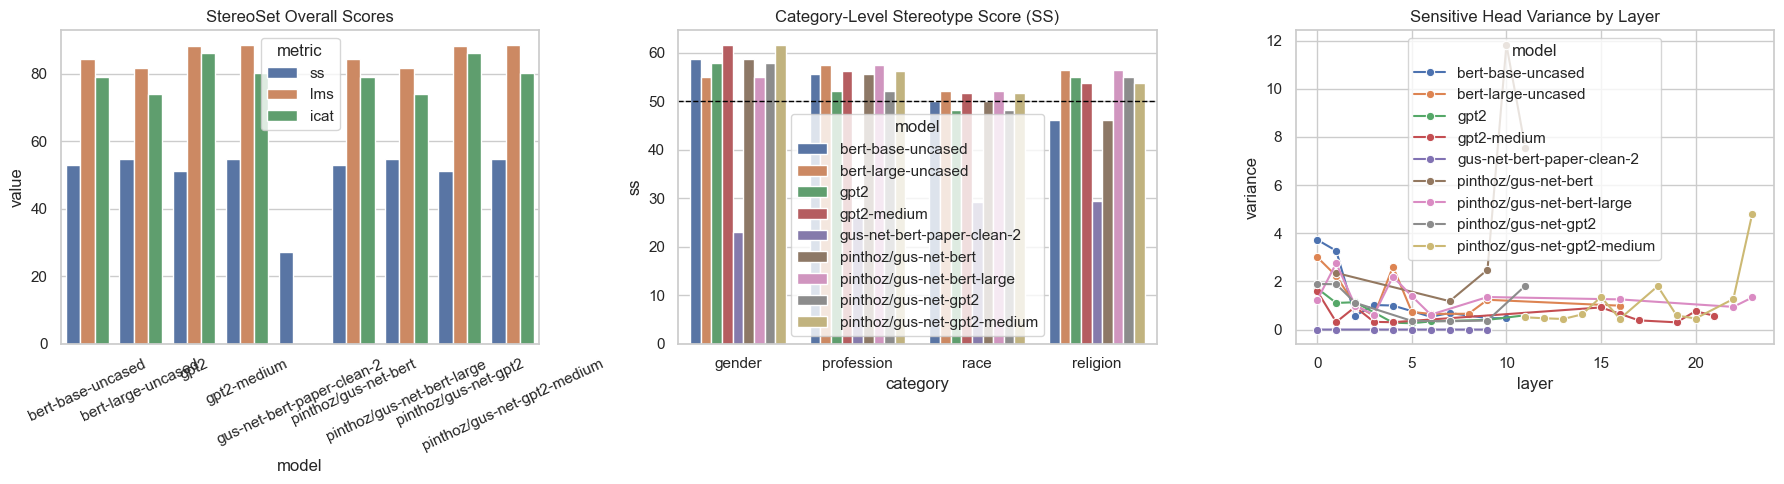

In [ ]:
# Create publication-style StereoSet figures for overall scores, category-level SS, and sensitive-head concentration by layer.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

overall_melt = stereoset_overall_df.melt(id_vars=['model'], value_vars=['ss', 'lms', 'icat'], var_name='metric', value_name='value')
sns.barplot(data=overall_melt, x='model', y='value', hue='metric', ax=axes[0])
axes[0].set_title('StereoSet Overall Scores')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=stereoset_category_df, x='category', y='ss', hue='model', ax=axes[1])
axes[1].axhline(50, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Category-Level Stereotype Score (SS)')

head_layer_df = stereoset_heads_df.groupby(['model', 'layer'], as_index=False)['variance'].sum()
sns.lineplot(data=head_layer_df, x='layer', y='variance', hue='model', marker='o', ax=axes[2])
axes[2].set_title('Sensitive Head Variance by Layer')

plt.tight_layout()
plt.show()

In [28]:
# Summarize the strongest benchmark conclusions in a concise thesis-ready table.

best_icat = stereoset_overall_df.sort_values('icat', ascending=False).iloc[0]
most_biased = stereoset_overall_df.sort_values('ss', ascending=False).iloc[0]
least_biased = stereoset_overall_df.iloc[(stereoset_overall_df['ss'] - 50).abs().argsort()].iloc[0]

stereoset_conclusion_df = pd.DataFrame([
    {'claim': 'Best balanced benchmark score', 'evidence': f"{best_icat['model']} has the highest ICAT ({best_icat['icat']})."},
    {'claim': 'Strongest stereotypical preference', 'evidence': f"{most_biased['model']} has the highest SS ({most_biased['ss']})."},
    {'claim': 'Closest to the unbiased SS baseline', 'evidence': f"{least_biased['model']} is closest to SS=50 with SS={least_biased['ss']}."},
])
stereoset_conclusion_df.to_csv(OUT_DIR / 'stereoset_conclusion_table.csv', index=False)
stereoset_conclusion_df

,claim,evidence
0,Best balanced benchmark score,gpt2 has the highest ICAT (86.05).
1,Strongest stereotypical preference,gpt2-medium has the highest SS (54.69).
2,Closest to the unbiased SS baseline,gpt2 is closest to SS=50 with SS=51.15.
